# 07 — Comparación final, conclusiones y caminos futuros

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

Este notebook consolida los resultados de todos los modelos entrenados (notebooks 02–06) y cierra el trabajo. Todos comparten exactamente los mismos datos (parquets de `data/processed/`), el mismo preprocesador (`build_preprocessor`, con escalado solo donde el modelo lo exige) y el mismo protocolo de validación (KFold-5, seed 42, solo train).

**Estructura:**

1. **Selección del ganador por validación** — el ranking que decide, calculado sin tocar el test.
2. **Análisis de error** — dónde falla el modelo y qué significa eso para la gestión de camas.
3. **Bootstrap pareado** — si las diferencias entre modelos sobreviven al azar del muestreo.
4. **Ablación del filtro heredado** — cuánto costó una decisión de preprocesamiento arrastrada sin auditar.
5. **Lectura global** y 6. **Conclusiones** — las tres preguntas del notebook 01, respondidas.

El test se abre **una sola vez y después de elegir**, sobre los 20.354 encuentros completos que conservan las estadías largas que el train filtró: el escenario honesto de producción.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.evaluacion import RUTA_METRICAS


## 1. Selección del ganador: por validación, no por test

El trabajo declara desde el notebook 01 que el test se abre **una sola vez**. Esa promesa se rompe si el ganador se corona mirando la tabla de test — aunque cada modelo se haya evaluado una única vez, *elegir* con esos números es usar el test como criterio de decisión.

Por eso la comparación se hace en dos pasos separados y en este orden:

1. **Selección** — ranking por `mae_cv`: el MAE de validación cruzada de cada familia, todos calculados con el **mismo protocolo** (KFold-5, `shuffle=True`, seed 42, exclusivamente sobre el train). Homologar este número tuvo un costo real: SVR-RBF y XGBoost habían buscado sus hiperparámetros con protocolos más baratos (submuestra de 16k y holdout interno del 10%), así que sus `mae_cv` se **recalcularon** con KFold-5 sobre el train completo en los notebooks 04 y 06. Sin esa corrección, la comparación los habría favorecido con números optimistas obtenidos sobre menos datos.
2. **Reporte** — recién con el ganador ya elegido se abre el test, para estimar sin sesgo cuál sería su error en producción.

**Una asimetría que conviene declarar.** El protocolo de *cálculo* de `mae_cv` es el mismo para las diez filas, pero el de *selección* no lo es. KNN (mejor de 32 configuraciones), el árbol podado (mejor de 25 valores de α), LinearSVR (mejor de 18) y Random Forest (mejor de 30 trials) reportan el **mínimo sobre la misma validación cruzada con la que después se los rankea**, y ese mínimo está optimistamente sesgado por *winner’s curse*: elegir el mejor de N estimaciones ruidosas captura también parte del ruido. SVR-RBF y XGBoost no arrastran ese sesgo, porque su `mae_cv` se recalculó después, con la configuración ya fijada. La asimetría juega **en contra del ganador** —sus rivales llegan al ranking con el número inflado a favor y aun así pierden—, así que no amenaza la conclusión; pero presentar como homogéneo un número que no lo es del todo sí sería un descuido.

La celda siguiente ejecuta el paso 1.

In [2]:
# --- PASO 1: seleccion del ganador POR VALIDACION (nunca por test) ---
tabla = pd.read_csv(RUTA_METRICAS)

es_baseline = tabla["modelo"].str.startswith("baseline")
candidatos = tabla[~es_baseline].sort_values("mae_cv").reset_index(drop=True)

vista_cv = candidatos[["modelo", "mae_cv"]].copy()
vista_cv.columns = ["modelo", "MAE validacion (dias)"]
vista_cv.insert(0, "puesto", range(1, len(vista_cv) + 1))

GANADOR = candidatos.loc[0, "modelo"]
print("Ranking por VALIDACION CRUZADA (KFold-5, seed 42, solo train).")
print("Este es el unico criterio con el que se elige el ganador:")
print()
print(vista_cv.round(4).to_string(index=False))
print()
print(f"GANADOR POR VALIDACION: {GANADOR}")
print()
print("Recien ahora se abre el test, y solo para estimar sin sesgo su error.")


Ranking por VALIDACION CRUZADA (KFold-5, seed 42, solo train).
Este es el unico criterio con el que se elige el ganador:

 puesto           modelo  MAE validacion (dias)
      1          xgboost                 1.6073
      2          svr_rbf                 1.6283
      3    random_forest                 1.6530
      4              knn                 1.6775
      5       svr_lineal                 1.6795
      6 regresion_lineal                 1.7081
      7     arbol_podado                 1.7362

GANADOR POR VALIDACION: xgboost

Recien ahora se abre el test, y solo para estimar sin sesgo su error.


In [3]:
# --- PASO 2: reporte sobre el test (una unica pasada, ya elegido el ganador) ---
PISO = tabla.loc[tabla["modelo"] == "baseline_mediana_sin_filtrar", "mae"].iloc[0]

orden_cv = tabla.sort_values("mae_cv").reset_index(drop=True)
vista = orden_cv[["modelo", "mae_cv", "mae", "rmse", "r2", "tiempo_s", "pred_test_s"]].copy()
vista.columns = ["modelo", "MAE val.", "MAE test", "RMSE", "R2", "refit (s)", "pred. test (s)"]
vista["vs piso"] = (vista["MAE test"] - PISO).round(3)

# ?Coincide el ranking de validacion con el de test? Es la pregunta que dice si
# elegir por CV en vez de por test habria cambiado la decision.
cand_cv = list(candidatos.sort_values("mae_cv")["modelo"])
cand_test = list(candidatos.sort_values("mae")["modelo"])
print(f"Orden por validacion: {cand_cv}")
print(f"Orden por test      : {cand_test}")
print(f"?Mismo ganador? {cand_cv[0] == cand_test[0]}   ?Mismo orden completo? {cand_cv == cand_test}")
print()
print(f"Piso honesto (mejor constante sin mirar el test): MAE {PISO:.4f} dias")
vista.round(4)


Orden por validacion: ['xgboost', 'svr_rbf', 'random_forest', 'knn', 'svr_lineal', 'regresion_lineal', 'arbol_podado']
Orden por test      : ['xgboost', 'svr_rbf', 'random_forest', 'knn', 'svr_lineal', 'arbol_podado', 'regresion_lineal']
?Mismo ganador? True   ?Mismo orden completo? False

Piso honesto (mejor constante sin mirar el test): MAE 2.2596 dias


,modelo,MAE val.,MAE test,RMSE,R2,refit (s),pred. test (s),vs piso
0,xgboost,1.6073,1.7477,2.4175,0.3441,13.04,0.18,-0.512
1,svr_rbf,1.6283,1.7687,2.4425,0.3304,123.31,94.09,-0.491
2,random_forest,1.6530,1.7980,2.3994,0.3539,10.37,0.38,-0.462
3,knn,1.6775,1.8341,2.4731,0.3136,0.13,8.15,-0.425
4,svr_lineal,1.6795,1.8343,2.5168,0.2891,0.27,0.02,-0.425
5,regresion_lineal,1.7081,1.8616,2.4666,0.3171,0.11,0.03,-0.398
6,arbol_podado,1.7362,1.8585,2.4829,0.3081,5.90,0.02,-0.401
7,baseline_mediana,2.0281,2.2929,3.2952,-0.2187,0.05,0.01,0.033
8,baseline_mediana_sin_filtrar,2.0429,2.2596,3.0111,-0.0176,0.00,0.00,0.000
9,baseline_media,2.0689,2.2805,3.0009,-0.0107,0.05,0.01,0.021


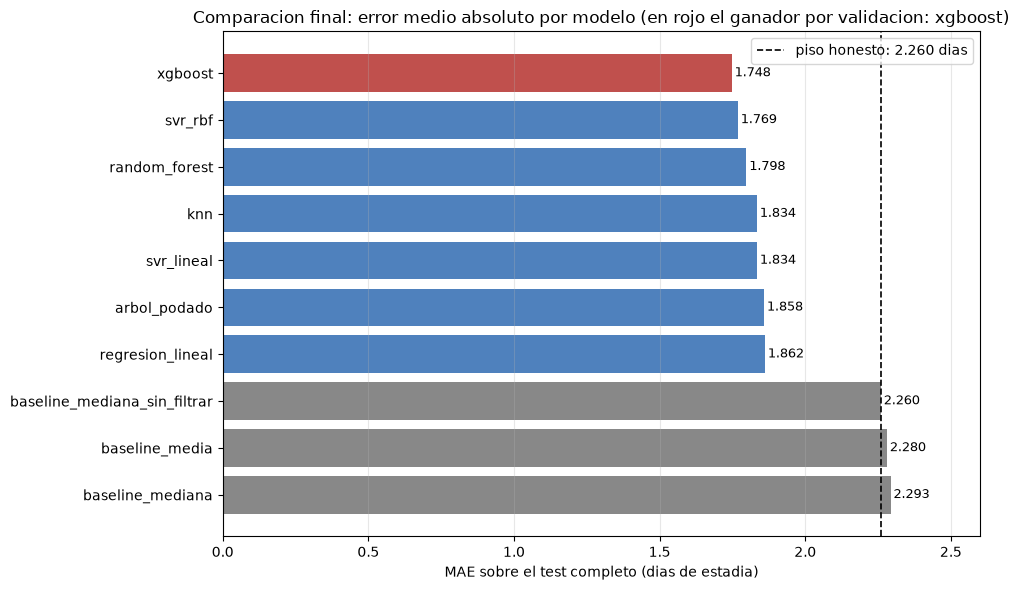

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
orden = tabla.sort_values("mae", ascending=False)
colores = []
for m in orden["modelo"]:
    if m.startswith("baseline"):
        colores.append("#888888")
    elif m == GANADOR:
        colores.append("#c0504d")
    else:
        colores.append("#4f81bd")

ax.barh(orden["modelo"], orden["mae"], color=colores)
ax.axvline(PISO, color="black", linestyle="--", linewidth=1.2,
           label=f"piso honesto: {PISO:.3f} dias")
for i, (_, fila) in enumerate(orden.iterrows()):
    ax.text(fila["mae"] + 0.01, i, f"{fila['mae']:.3f}", va="center", fontsize=9)
ax.set_xlabel("MAE sobre el test completo (dias de estadia)")
ax.set_title(f"Comparacion final: error medio absoluto por modelo "
             f"(en rojo el ganador por validacion: {GANADOR})")
ax.legend(); ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, 2.6)
plt.tight_layout(); plt.show()


## 2. Dónde falla el modelo: análisis de error

Un MAE agregado de ~1,75 días no dice **dónde** se equivoca el modelo, y para la gestión de camas esa es la pregunta operativa: no es lo mismo errar medio día en una estadía corta que tres días en una larga. Esta sección desagrega el error por duración real de la estadía, muestra la forma de los residuos y traduce el desempeño a la métrica que un jefe de camas puede usar directamente: **qué porcentaje de pacientes cae dentro de una tolerancia de ± N días**.

Para hacerlo hacen falta las predicciones sobre el test de los tres mejores modelos, así que se reentrenan acá con la configuración exacta que quedó registrada. El test se usa únicamente para **medir**: ninguna decisión se toma con él.

In [5]:
# --- Se reentrenan los tres mejores para tener sus predicciones sobre el test ---
# (necesarias para el analisis de error y el bootstrap pareado; el test se usa
#  solo para MEDIR, ninguna decision se toma con el)
# Las predicciones se cachean en resultados/predicciones/ para que re-ejecutar
# este notebook no vuelva a pagar el refit del SVR-RBF (~4 min entre fit y
# prediccion). La cache se invalida sola: la clave incluye los hiperparametros.
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from xgboost import XGBRegressor

from src.config import DIR_PROCESSED, DIR_RESULTADOS, SEED, STORAGE_OPTUNA, TARGET
from src.pipelines import build_preprocessor

X_train = pd.read_parquet(DIR_PROCESSED / "X_train.parquet")
X_test = pd.read_parquet(DIR_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DIR_PROCESSED / "y_train.parquet")[TARGET]
y_test = pd.read_parquet(DIR_PROCESSED / "y_test.parquet")[TARGET]

optuna.logging.set_verbosity(optuna.logging.WARNING)
est_xgb = optuna.load_study(study_name="xgboost_d7", storage=STORAGE_OPTUNA)
est_rf = optuna.load_study(study_name="random_forest", storage=STORAGE_OPTUNA)
est_rbf = optuna.load_study(study_name="svr_rbf_sub16k", storage=STORAGE_OPTUNA)
ronda_xgb = est_xgb.best_trial.user_attrs["mejor_ronda"]

modelos_finales = {
    "xgboost": Pipeline([
        ("preprocesador", build_preprocessor(scale=False)),
        ("modelo", XGBRegressor(
            objective="reg:absoluteerror", n_estimators=max(ronda_xgb, 1),
            tree_method="hist", random_state=SEED, n_jobs=-1, verbosity=0,
            **est_xgb.best_params)),
    ]),
    "random_forest": Pipeline([
        ("preprocesador", build_preprocessor(scale=False)),
        ("modelo", RandomForestRegressor(
            random_state=SEED, n_jobs=-1, **est_rf.best_params)),
    ]),
    "svr_rbf": Pipeline([
        ("preprocesador", build_preprocessor(scale=True)),
        ("modelo", SVR(kernel="rbf", cache_size=500, **est_rbf.best_params)),
    ]),
}
firmas = {
    "xgboost": f"n{ronda_xgb}_" + "_".join(f"{v:.6g}" for _, v in sorted(est_xgb.best_params.items())),
    "random_forest": "_".join(f"{v:.6g}" for _, v in sorted(est_rf.best_params.items())),
    "svr_rbf": "_".join(f"{v:.6g}" for _, v in sorted(est_rbf.best_params.items())),
}

DIR_PRED = DIR_RESULTADOS / "predicciones"
DIR_PRED.mkdir(parents=True, exist_ok=True)

predicciones = {}
for nombre, pipe in modelos_finales.items():
    ruta = DIR_PRED / f"{nombre}__{firmas[nombre]}.npy"
    if ruta.exists():
        predicciones[nombre] = np.load(ruta)
        print(f"{nombre:15s} predicciones leidas de cache")
        continue
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    predicciones[nombre] = pipe.predict(X_test)
    np.save(ruta, predicciones[nombre])
    print(f"{nombre:15s} reentrenado y cacheado en {time.perf_counter() - t0:6.1f} s")

# Control de integridad: las predicciones deben reproducir el MAE ya registrado
print()
for nombre, pr in predicciones.items():
    mae_ahora = float(np.abs(y_test - pr).mean())
    mae_csv = float(tabla.loc[tabla["modelo"] == nombre, "mae"].iloc[0])
    ok = "OK" if abs(mae_ahora - mae_csv) < 1e-9 else "DISCREPANCIA"
    print(f"{nombre:15s} MAE recalculado {mae_ahora:.6f} vs registrado {mae_csv:.6f}  {ok}")


xgboost         predicciones leidas de cache
random_forest   predicciones leidas de cache
svr_rbf         predicciones leidas de cache

xgboost         MAE recalculado 1.747695 vs registrado 1.747695  OK
random_forest   MAE recalculado 1.797975 vs registrado 1.797975  OK
svr_rbf         MAE recalculado 1.768658 vs registrado 1.768658  OK


In [6]:
# --- ANALISIS DE ERROR del ganador: donde acierta y donde falla ---
pred = predicciones[GANADOR]
residuo = y_test - pred                    # positivo = el modelo SUBESTIMO la estadia

por_dia = pd.DataFrame({"real": y_test, "pred": pred, "residuo": residuo})
resumen = por_dia.groupby("real").agg(
    n=("real", "size"),
    pred_media=("pred", "mean"),
    mae=("residuo", lambda r: r.abs().mean()),
    sesgo=("residuo", "mean"),
).reset_index()

print(f"Analisis de error de {GANADOR} por duracion REAL de la estadia")
print("(sesgo > 0 = el modelo predice MENOS dias de los reales)")
print()
print(resumen.round(3).to_string(index=False))


Analisis de error de xgboost por duracion REAL de la estadia
(sesgo > 0 = el modelo predice MENOS dias de los reales)

 real    n  pred_media   mae  sesgo
  1.0 2842       2.611 1.613 -1.611
  2.0 3445       3.063 1.136 -1.063
  3.0 3551       3.494 0.901 -0.494
  4.0 2785       3.905 0.988  0.095
  5.0 1993       4.303 1.339  0.697
  6.0 1508       4.644 1.760  1.356
  7.0 1172       4.984 2.178  2.016
  8.0  878       5.351 2.725  2.649
  9.0  601       5.507 3.505  3.493
 10.0  468       5.778 4.222  4.222
 11.0  371       5.874 5.126  5.126
 12.0  290       6.179 5.821  5.821
 13.0  242       6.273 6.727  6.727
 14.0  208       6.521 7.479  7.479


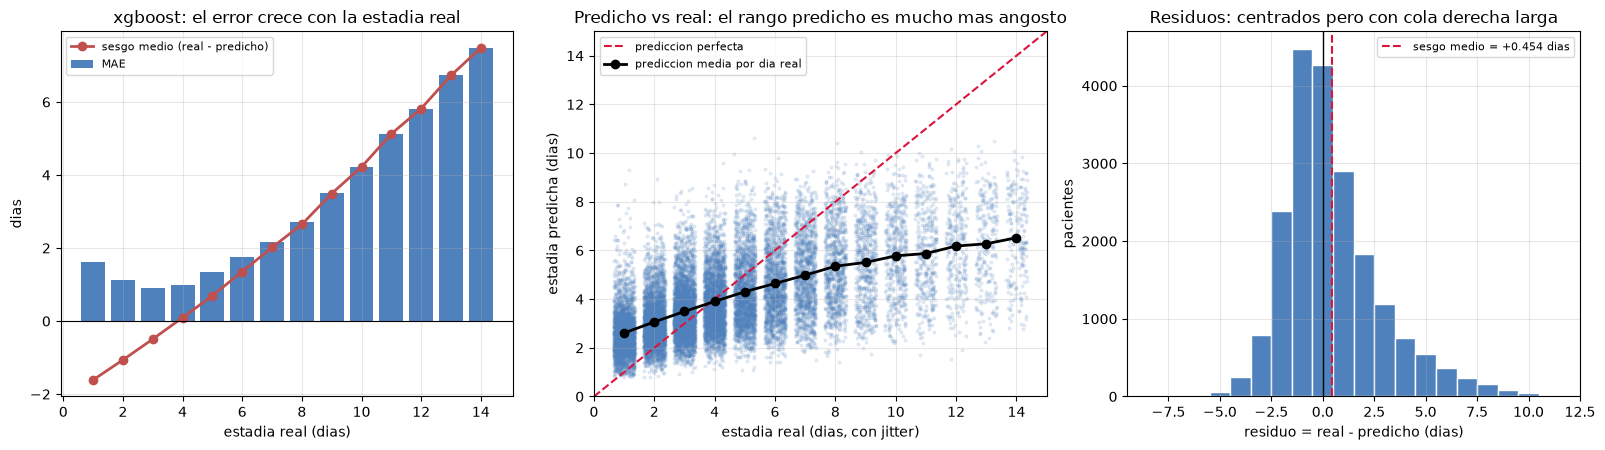

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) MAE y sesgo por duracion real
axes[0].bar(resumen["real"], resumen["mae"], color="#4f81bd", label="MAE")
axes[0].plot(resumen["real"], resumen["sesgo"], color="#c0504d", marker="o",
             linewidth=2, label="sesgo medio (real - predicho)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("estadia real (dias)")
axes[0].set_ylabel("dias")
axes[0].set_title(f"{GANADOR}: el error crece con la estadia real")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# (b) predicho vs real
axes[1].scatter(y_test + np.random.default_rng(SEED).uniform(-0.35, 0.35, len(y_test)),
                pred, s=4, alpha=0.12, color="#4f81bd")
lim = [0, 15]
axes[1].plot(lim, lim, color="crimson", linestyle="--", linewidth=1.5,
             label="prediccion perfecta")
axes[1].plot(resumen["real"], resumen["pred_media"], color="black", marker="o",
             linewidth=2, label="prediccion media por dia real")
axes[1].set_xlim(0, 15); axes[1].set_ylim(0, 15)
axes[1].set_xlabel("estadia real (dias, con jitter)")
axes[1].set_ylabel("estadia predicha (dias)")
axes[1].set_title("Predicho vs real: el rango predicho es mucho mas angosto")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# (c) distribucion de residuos
axes[2].hist(residuo, bins=np.arange(-8.5, 12.5, 1), color="#4f81bd",
             edgecolor="white")
axes[2].axvline(0, color="black", linewidth=1)
axes[2].axvline(residuo.mean(), color="crimson", linestyle="--",
                label=f"sesgo medio = {residuo.mean():+.3f} dias")
axes[2].set_xlabel("residuo = real - predicho (dias)")
axes[2].set_ylabel("pacientes")
axes[2].set_title("Residuos: centrados pero con cola derecha larga")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [8]:
# --- La metrica que un jefe de camas puede usar: aciertos dentro de tolerancia ---
err_abs = np.abs(residuo)
print(f"Modelo: {GANADOR}  (n = {len(y_test):,} pacientes de test)")
print()
for tol in [0.5, 1, 2, 3]:
    pct = 100 * (err_abs <= tol).mean()
    print(f"  predicciones dentro de +/- {tol:<4} dia(s): {pct:5.1f}%")
print()

# Comparacion contra el piso honesto: la mediana del train SIN filtrar (NB02).
# Se recalcula desde el origen en lugar de hardcodearla.
from src.preprocesamiento import cargar_y_limpiar, split_estratificado

_X, _y = cargar_y_limpiar()
_, _, _y_train_sin_filtrar, _ = split_estratificado(_X, _y)
CONSTANTE_PISO = float(_y_train_sin_filtrar.median())
err_piso = np.abs(y_test - CONSTANTE_PISO)
print(f"Piso honesto = predecir siempre {CONSTANTE_PISO:.1f} dias "
      f"(mediana del train sin filtrar)")
print()
print("Contra el piso honesto:")
for tol in [1, 2]:
    print(f"  +/- {tol} dia(s): modelo {100 * (err_abs <= tol).mean():5.1f}%  "
          f"vs piso {100 * (err_piso <= tol).mean():5.1f}%  "
          f"(+{100 * ((err_abs <= tol).mean() - (err_piso <= tol).mean()):.1f} pts)")
print()

# Donde se concentra el error total: los pocos casos largos pesan mucho
largos = y_test >= 9
print(f"Pacientes con estadia >= 9 dias: {int(largos.sum()):,} "
      f"({100 * largos.mean():.1f}% del test)")
print(f"  concentran el {100 * err_abs[largos].sum() / err_abs.sum():.1f}% del error absoluto total")
print(f"  MAE en ese grupo: {err_abs[largos].mean():.2f} dias "
      f"(vs {err_abs[~largos].mean():.2f} en el resto)")


Modelo: xgboost  (n = 20,354 pacientes de test)

  predicciones dentro de +/- 0.5  dia(s):  21.0%
  predicciones dentro de +/- 1    dia(s):  40.8%
  predicciones dentro de +/- 2    dia(s):  69.5%
  predicciones dentro de +/- 3    dia(s):  83.6%



Piso honesto = predecir siempre 4.0 dias (mediana del train sin filtrar)

Contra el piso honesto:
  +/- 1 dia(s): modelo  40.8%  vs piso  40.9%  (+-0.1 pts)
  +/- 2 dia(s): modelo  69.5%  vs piso  65.3%  (+4.2 pts)

Pacientes con estadia >= 9 dias: 2,180 (10.7% del test)
  concentran el 30.5% del error absoluto total
  MAE en ese grupo: 4.98 dias (vs 1.36 en el resto)


## 3. ¿Las diferencias entre modelos son reales o son ruido?

Las distancias entre los modelos no lineales son de centésimas de día. Antes de afirmar que uno "gana", hay que verificar que la diferencia sobrevive al azar del muestreo. La celda siguiente hace un **bootstrap pareado**: remuestrea los 20.354 pacientes del test 10.000 veces y recalcula la diferencia de MAE entre cada rival y el ganador **sobre los mismos pacientes**, de modo que la comparación no se contamina con qué caso difícil le tocó a cada modelo.

In [9]:
# --- ?Las diferencias entre los mejores modelos son distinguibles del ruido? ---
# Bootstrap PAREADO sobre los errores absolutos: se remuestrean pacientes (no
# modelos), de modo que la comparacion controla por que paciente le toco a cada
# cual. 10.000 repeticiones, seed 42. Se procesa por bloques para no materializar
# una matriz de 10.000 x 20.354 indices de una sola vez.
rng = np.random.default_rng(SEED)
B, BLOQUE = 10_000, 250
n = len(y_test)

errores = {m: np.abs(y_test.values - p) for m, p in predicciones.items()}
dist_mae = {m: [] for m in errores}
dist_dif = {m: [] for m in errores if m != GANADOR}

for inicio in range(0, B, BLOQUE):
    k = min(BLOQUE, B - inicio)
    idx = rng.integers(0, n, size=(k, n))
    for m, e in errores.items():
        dist_mae[m].append(e[idx].mean(axis=1))
    for m in dist_dif:
        dist_dif[m].append((errores[m] - errores[GANADOR])[idx].mean(axis=1))

dist_mae = {m: np.concatenate(v) for m, v in dist_mae.items()}
dist_dif = {m: np.concatenate(v) for m, v in dist_dif.items()}

print(f"MAE sobre el test con intervalo de confianza bootstrap del 95% "
      f"({B:,} remuestreos):")
for m, e in sorted(errores.items(), key=lambda kv: kv[1].mean()):
    lo, hi = np.percentile(dist_mae[m], [2.5, 97.5])
    print(f"  {m:15s} {e.mean():.4f}   IC95 [{lo:.4f}, {hi:.4f}]   "
          f"(error estandar {dist_mae[m].std():.4f})")
print()
print(f"Diferencia PAREADA de MAE contra el ganador ({GANADOR}); "
      "positivo = el rival es PEOR:")
print()
for m in dist_dif:
    dif = errores[m] - errores[GANADOR]
    lo, hi = np.percentile(dist_dif[m], [2.5, 97.5])
    p_empata = float((dist_dif[m] <= 0).mean())
    veredicto = ("SIGNIFICATIVA (el IC no cruza 0)" if lo > 0
                 else "NO distinguible de 0 (el IC cruza 0)")
    print(f"  vs {m:15s} {dif.mean():+.4f} dias   IC95 [{lo:+.4f}, {hi:+.4f}]")
    print(f"     -> {veredicto}")
    print(f"     -> en el {100 * p_empata:.1f}% de los remuestreos {m} igualaria "
          f"o superaria al ganador")
    print()


MAE sobre el test con intervalo de confianza bootstrap del 95% (10,000 remuestreos):
  xgboost         1.7477   IC95 [1.7248, 1.7709]   (error estandar 0.0119)
  svr_rbf         1.7687   IC95 [1.7452, 1.7922]   (error estandar 0.0120)
  random_forest   1.7980   IC95 [1.7760, 1.8200]   (error estandar 0.0113)

Diferencia PAREADA de MAE contra el ganador (xgboost); positivo = el rival es PEOR:

  vs random_forest   +0.0503 dias   IC95 [+0.0439, +0.0565]
     -> SIGNIFICATIVA (el IC no cruza 0)
     -> en el 0.0% de los remuestreos random_forest igualaria o superaria al ganador

  vs svr_rbf         +0.0210 dias   IC95 [+0.0155, +0.0264]
     -> SIGNIFICATIVA (el IC no cruza 0)
     -> en el 0.0% de los remuestreos svr_rbf igualaria o superaria al ganador



## 4. Ablación: cuánto costó el filtro heredado

La auditoría del notebook 01 mostró que el filtro IQR portado del trabajo de Análisis de Datos no es lo que su nombre sugiere: en `number_outpatient` y `number_emergency` el rango intercuartílico es **cero**, así que sus límites colapsan a `[0, 0]` y el criterio se convierte en *"conservar solo pacientes sin visitas previas"*. Entre esas dos columnas y `number_inpatient` — ninguna de las cuales es una feature del modelo — se va el 34% del train, y el 32,5% del test queda sin análogos en el entrenamiento.

Esa decisión se mantuvo en el pipeline principal por fidelidad al trabajo original y para que las diez filas de `metricas.csv` sean comparables entre sí. Pero mantenerla sin medirla sería aceptar a ciegas la herencia. La ablación siguiente reentrena el **modelo ganador con hiperparámetros idénticos** sobre el train sin filtrar y lo evalúa sobre el **mismo test**: la única variable que cambia es el filtro. Después, el costo que resulte pasa por el **mismo bootstrap pareado** de la sección 3: un número que las conclusiones van a comparar con la ventaja entre modelos tiene que estar medido con la misma vara que esa ventaja.

In [10]:
# --- ABLACION: cuanto cuesta el filtro IQR heredado del trabajo de AdD? ---
# El NB01 auditó el filtro y mostro que descarta el 34% del train, sobre todo
# por dos columnas cuyo IQR es CERO (number_outpatient, number_emergency) y que
# ni siquiera son features. Aca se mide el costo: se reentrena el modelo GANADOR
# con hiperparametros IDENTICOS sobre el train sin filtrar y se evalua sobre el
# MISMO test. Todo lo demas se mantiene constante.
from sklearn.metrics import mean_absolute_error, r2_score

from src.config import FEATURES_FINALES

X_todo, y_todo = cargar_y_limpiar()
X_tr_sin, X_te_chk, y_tr_sin, y_te_chk = split_estratificado(X_todo, y_todo)
X_tr_sin = X_tr_sin[FEATURES_FINALES].reset_index(drop=True)
y_tr_sin = y_tr_sin.reset_index(drop=True)

# Control: el test de la ablacion tiene que ser exactamente el mismo de siempre
X_te_chk = X_te_chk[FEATURES_FINALES].reset_index(drop=True)
y_te_chk = y_te_chk.reset_index(drop=True)
assert X_te_chk.equals(X_test) and y_te_chk.equals(y_test), \
    "el test de la ablacion debe ser identico al usado en todo el trabajo"

pipe_ablacion = modelos_finales[GANADOR]
from sklearn.base import clone
pipe_ablacion = clone(pipe_ablacion)

t0 = time.perf_counter()
pipe_ablacion.fit(X_tr_sin, y_tr_sin)
t_abl = time.perf_counter() - t0
pred_abl = pipe_ablacion.predict(X_test)

comparacion_abl = pd.DataFrame({
    "train (filas)": [len(X_train), len(X_tr_sin)],
    "MAE test": [mean_absolute_error(y_test, pred), mean_absolute_error(y_test, pred_abl)],
    "R2 test": [r2_score(y_test, pred), r2_score(y_test, pred_abl)],
}, index=[f"{GANADOR} CON filtro (resultado oficial)",
          f"{GANADOR} SIN filtro (ablacion)"])

print(f"Ablacion del filtro IQR sobre el modelo ganador ({GANADOR}),")
print("mismos hiperparametros, mismo test, unica diferencia = el filtro.")
print()
print(comparacion_abl.round(4).to_string())
print()
d_mae = comparacion_abl["MAE test"].iloc[1] - comparacion_abl["MAE test"].iloc[0]
d_r2 = comparacion_abl["R2 test"].iloc[1] - comparacion_abl["R2 test"].iloc[0]
print(f"Efecto de QUITAR el filtro: MAE {d_mae:+.4f} dias | R2 {d_r2:+.4f}")
print(f"(refit sin filtro: {t_abl:.1f} s sobre {len(X_tr_sin):,} filas)")


Ablacion del filtro IQR sobre el modelo ganador (xgboost),
mismos hiperparametros, mismo test, unica diferencia = el filtro.

                                        train (filas)  MAE test  R2 test
xgboost CON filtro (resultado oficial)          53756    1.7477   0.3441
xgboost SIN filtro (ablacion)                   81412    1.7264   0.3618

Efecto de QUITAR el filtro: MAE -0.0212 dias | R2 +0.0178
(refit sin filtro: 19.5 s sobre 81,412 filas)


In [11]:
# ?De donde sale la mejora? De los pacientes que el filtro excluia del train.
from src.config import COLS_FILTRO_IQR

# Se reconstruyen los limites del filtro con el mismo criterio del NB01,
# calculados sobre el train antes de filtrar.
X_tr_bruto, X_te_bruto, y_tr_bruto, _ = split_estratificado(X_todo, y_todo)
limites = {}
for col in COLS_FILTRO_IQR:
    q1, q3 = X_tr_bruto[col].quantile(0.25), X_tr_bruto[col].quantile(0.75)
    iqr = q3 - q1
    limites[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

dentro = pd.Series(True, index=X_te_bruto.index)
for col, (inf, sup) in limites.items():
    dentro &= X_te_bruto[col].between(inf, sup)
mask = dentro.values          # el orden del split se conserva: indexacion posicional

err_con = np.abs(y_test.values - pred)
err_sin = np.abs(y_test.values - pred_abl)

seg = pd.DataFrame({
    "n": [int(mask.sum()), int((~mask).sum())],
    "MAE con filtro": [err_con[mask].mean(), err_con[~mask].mean()],
    "MAE sin filtro": [err_sin[mask].mean(), err_sin[~mask].mean()],
}, index=["test DENTRO de la subpoblacion del train filtrado",
          "test FUERA (los pacientes que el filtro excluia)"])
seg["mejora"] = seg["MAE con filtro"] - seg["MAE sin filtro"]

print(seg.round(4).to_string())
print()
print("La mejora se concentra donde tenia que concentrarse: en los pacientes que")
print("el filtro borraba del entrenamiento y que el test si contiene.")


                                                       n  MAE con filtro  MAE sin filtro  mejora
test DENTRO de la subpoblacion del train filtrado  13742          1.7222          1.7127  0.0095
test FUERA (los pacientes que el filtro excluia)    6612          1.8007          1.7550  0.0457

La mejora se concentra donde tenia que concentrarse: en los pacientes que
el filtro borraba del entrenamiento y que el test si contiene.


In [12]:
# --- ?El costo del filtro es distinguible del ruido? ---
# La conclusion titular del trabajo equipara los 0.021 dias que cuesta el filtro
# con la ventaja del ganador sobre su rival mas cercano (0.0210 dias), que SI
# esta testeada por bootstrap. Aplicarle una vara mas laxa al numero propio que
# a la comparacion entre modelos seria justamente el sesgo que este notebook
# viene evitando: se le corre el MISMO test.
#
# Pareado y sobre los mismos pacientes: ambos modelos predicen sobre el test
# completo, asi que la diferencia se mide paciente por paciente y no se
# contamina con que caso dificil le toco a cada remuestreo.
rng_abl = np.random.default_rng(SEED)
dif_abl = err_con - err_sin          # positivo = el filtro EMPEORA la prediccion

dist_abl = []
for inicio in range(0, B, BLOQUE):
    k = min(BLOQUE, B - inicio)
    idx = rng_abl.integers(0, n, size=(k, n))
    dist_abl.append(dif_abl[idx].mean(axis=1))
dist_abl = np.concatenate(dist_abl)

lo_abl, hi_abl = np.percentile(dist_abl, [2.5, 97.5])
p_nulo = float((dist_abl <= 0).mean())

print(f"Costo del filtro IQR sobre el MAE de test (bootstrap pareado, {B:,} remuestreos):")
print()
print(f"  diferencia observada (CON filtro - SIN filtro): {dif_abl.mean():+.4f} dias")
print(f"  IC95: [{lo_abl:+.4f}, {hi_abl:+.4f}]   (error estandar {dist_abl.std():.4f})")
print(f"  en el {100 * p_nulo:.1f}% de los remuestreos el filtro no empeora nada")
print()
print("Referencia -- la ventaja del ganador sobre su rival mas cercano, medida")
print(f"con este mismo procedimiento: {dist_dif['svr_rbf'].mean():+.4f} dias "
      f"IC95 [{np.percentile(dist_dif['svr_rbf'], 2.5):+.4f}, "
      f"{np.percentile(dist_dif['svr_rbf'], 97.5):+.4f}]")
print()
if lo_abl > 0:
    print("=> El costo del filtro es DISTINGUIBLE DE CERO con la misma vara que")
    print("   separo a los modelos entre si. La equiparacion de las conclusiones")
    print("   ('el filtro costo lo mismo que toda la ventaja del ganador') pone")
    print("   lado a lado dos efectos ambos significativos, no uno real contra")
    print("   uno que podria ser ruido de muestreo.")
else:
    print("=> El IC95 cruza cero: el costo del filtro NO se distingue del ruido")
    print("   de muestreo, y la equiparacion con la ventaja del ganador no se")
    print("   sostiene. Habria que enunciarla como conjetura, no como medicion.")


Costo del filtro IQR sobre el MAE de test (bootstrap pareado, 10,000 remuestreos):

  diferencia observada (CON filtro - SIN filtro): +0.0212 dias
  IC95: [+0.0166, +0.0260]   (error estandar 0.0024)
  en el 0.0% de los remuestreos el filtro no empeora nada

Referencia -- la ventaja del ganador sobre su rival mas cercano, medida
con este mismo procedimiento: +0.0210 dias IC95 [+0.0155, +0.0264]

=> El costo del filtro es DISTINGUIBLE DE CERO con la misma vara que
   separo a los modelos entre si. La equiparacion de las conclusiones
   ('el filtro costo lo mismo que toda la ventaja del ganador') pone
   lado a lado dos efectos ambos significativos, no uno real contra
   uno que podria ser ruido de muestreo.


## 5. Lectura global

**Elegir por validación no cambió el ganador, pero sí lo volvió defendible.** El ranking por `mae_cv` y el ranking por test coinciden en el ganador (XGBoost) y en los cinco primeros puestos; solo discrepan en los dos últimos, donde la regresión lineal y el árbol podado intercambian lugares. Que el resultado no cambie es exactamente lo que uno espera cuando la validación está bien hecha — y no invalida el procedimiento: **la garantía no viene de que el orden coincida, sino de que la decisión se tomó sin mirar el test**. Si hubieran discrepado, habría ganado la validación.

**La brecha que importa está contra el piso, no entre modelos.** XGBoost (MAE 1,748) le recorta **0,512 días (−22,7%)** a la mejor política ingenua honesta: predecir siempre 4 días, la mediana del train sin filtrar (MAE 2,260). Entre los cinco modelos no lineales — XGBoost 1,748, SVR-RBF 1,769, Random Forest 1,798, KNN 1,834, árbol podado 1,859 — la distancia total es de apenas **0,111 días**. Una vez capturada la no linealidad principal, la elección de familia mueve el resultado cinco veces menos que haberla capturado.

**Las diferencias entre los tres mejores son reales, pero chicas.** El bootstrap pareado (10.000 remuestreos de los 20.354 pacientes) las separa con claridad: XGBoost le gana a SVR-RBF por 0,021 días (IC95 [0,016, 0,026]) y a Random Forest por 0,050 días (IC95 [0,044, 0,057]); en ningún remuestreo el rival alcanza al ganador. Es decir: el orden **no** es ruido. Pero conviene leer la magnitud junto al intervalo del MAE en sí (±0,023 días), y sobre todo junto a la ablación — sometida al **mismo** bootstrap, para no aplicarle al número propio una vara más laxa que a la comparación entre modelos: **el filtro heredado costó 0,021 días (IC95 [0,017, 0,026]): el mismo efecto, y casi el mismo intervalo, que la ventaja del ganador sobre su rival recién citada.** Los dos son significativos y son del mismo tamaño: una decisión de preprocesamiento arrastrada sin auditar pesó tanto como la diferencia entre dos familias de algoritmos.

**Dónde falla el modelo: el error no está repartido.** El MAE global de 1,748 días esconde una estructura muy marcada. El error crece de forma monótona con la duración real: 0,90 días para estadías de 3 días, 2,18 para las de 7, **7,48 para las de 14**. El sesgo cambia de signo alrededor del día 4: el modelo **sobreestima** las estadías cortas y **subestima** sistemáticamente las largas, porque su predicción **media por grupo** apenas recorre 3,9 días —de 2,6 en los pacientes que se van a las 24 h a 6,5 en los que se quedan 14— para seguir una realidad que recorre 13. El 10,7% de pacientes con estadías de 9 días o más concentra el **30,5% de todo el error absoluto**, con un MAE de 4,98 días frente a 1,36 en el resto.

**El dato incómodo: con tolerancia de ±1 día, el modelo empata con la constante.** Traducido a la métrica que usaría un jefe de camas, XGBoost acierta dentro de ±1 día en el **40,8%** de los pacientes… y predecir siempre 4 días acierta en el **40,9%**. La ventaja del modelo recién aparece al ampliar la tolerancia: ±2 días, 69,5% contra 65,3% (+4,2 puntos). Esto no anula el valor del modelo — el MAE es 0,51 días mejor y eso es real —, pero sí precisa **para qué sirve**: no para acertar la fecha de alta de un paciente concreto, sino para estimar la carga agregada de camas, donde los errores de signo opuesto se compensan parcialmente. Presentarlo como una herramienta de predicción individual sería sobrevenderlo.

**Costo computacional: XGBoost gana en MAE y en latencia, no en todo.** Gana el MAE con 13 s de refit y 0,18 s para puntuar 20.354 pacientes. Su rival más cercano (SVR-RBF) paga **123 s de entrenamiento y 94 s por cada pasada de predicción** — inviable para re-puntuar la cartera de camas varias veces al día. Pero *no* domina toda la frontera: **Random Forest tiene mejor RMSE (2,399 vs 2,418) y mejor R² (0,354 vs 0,344)** del cuadro. Cada uno lidera la métrica que su función de pérdida favorece — XGBoost se entrenó con `reg:absoluteerror` (decisión D4) y optimiza el MAE; RF minimiza error cuadrático y controla mejor los errores grandes. Si la métrica de negocio fuera penalizar fuerte los desvíos extremos, la elección sería otra.

**La señal de negocio no depende del modelo.** La permutation importance sobre el test coincide entre dos ensambles de mecanismo opuesto (bagging y boosting): `num_medications` (0,34/0,33 días), `num_lab_procedures` (0,18/0,16) y `diag_1` (0,13/0,13) encabezan en ambos (NB06). La intensidad de tratamiento como predictor dominante es una propiedad de los datos, no un artefacto de la familia elegida.

**Interpretabilidad como criterio de desempate:** si el hospital exigiera reglas auditables, el árbol podado (MAE 1,859, 0,111 días peor que XGBoost) ofrece 326 hojas legibles, y la señal dominante —medicación y laboratorio— está disponible desde las primeras horas de la admisión.


## 6. Conclusiones

### Las tres preguntas del notebook 01, respondidas

**1. ¿Alcanza la información de la admisión para anticipar la estadía? ¿Dónde está el techo?**

Parcialmente, y el techo está bastante abajo. El mejor modelo alcanza **MAE 1,748 días y R² 0,344**: dos tercios de la varianza de la estadía quedan sin explicar. La hipótesis previa —que el límite estaría en los datos y no en los algoritmos— se sostiene, con tres evidencias independientes: (i) siete familias muy distintas convergen a un rango de 0,11 días, (ii) el error crece monótonamente con la duración real, señal de que a los casos largos les falta información que la admisión no contiene, y (iii) con tolerancia de ±1 día el modelo apenas empata con una constante.

Pero la ablación obliga a matizar el diagnóstico: **parte de ese techo era autoinfligido**. Quitando el filtro heredado, el mismo modelo con los mismos hiperparámetros pasa a MAE 1,726 y R² 0,362. No cambia la conclusión de fondo —el techo sigue estando en los datos— pero sí desautoriza la versión fuerte de la afirmación: antes de declarar un límite intrínseco hay que haber auditado las decisiones propias.

**2. ¿Qué variables de admisión gobiernan la duración: el diagnóstico o la intensidad de tratamiento?**

La **intensidad de tratamiento**, con claridad. `num_medications` y `num_lab_procedures` encabezan el ranking de permutation importance en dos ensambles de mecanismo opuesto, y `diag_1` (el diagnóstico primario) queda tercero; `diag_2` y `diag_3` se desploman a ~0,02 días. Lo que el hospital *hace* en las primeras horas predice mejor la estadía que lo que el paciente *tiene* codificado. La consecuencia operativa es concreta: el modelo puede correr temprano, sin esperar la codificación ICD-9 secundaria definitiva, que en muchos hospitales se completa días después del alta.

**3. ¿Cuánto importa la elección de la familia frente a la disciplina metodológica?**

Mucho menos. Los números del trabajo, puestos en la misma unidad:

| Decisión | Efecto sobre el MAE |
|---|---|
| Usar un modelo en lugar del piso ingenuo | **0,512 días** |
| Elegir la mejor familia en vez de la peor de las no lineales | 0,111 días |
| Auditar el filtro de outliers heredado | 0,021 días · IC95 [0,017, 0,026] |
| Elegir XGBoost en vez de SVR-RBF | 0,021 días · IC95 [0,016, 0,026] |

La ganancia de modelar supera en un factor de cinco a la de elegir bien la familia. Y una sola decisión de preprocesamiento no auditada pesó tanto como toda la ventaja del ganador sobre su rival más cercano. Es la tesis metodológica de la materia, medida sobre datos propios.

### Respuesta a la pregunta de investigación

*¿Cuántos días permanecerá internado un paciente diabético, estimado al momento de su ingreso?* XGBoost, sobre 8 variables de admisión, responde con un **error medio de 1,75 días**, contra 2,26 de la mejor política ingenua honesta: **0,51 días menos por paciente (−22,7%)**.

Qué significa eso operativamente, dicho con precisión: para un hospital con 10.000 admisiones diabéticas anuales, el modelo reduce en ~5.100 días el **error absoluto acumulado** de estimación. No son 5.100 días-cama liberados: los errores de sobreestimación y subestimación se compensan parcialmente al agregarse, así que el beneficio neto sobre la ocupación planificada es menor y depende de cómo se agregue por servicio y por período. El modelo corre con insumos disponibles en las primeras horas de la admisión, puntúa 20.354 pacientes en 0,18 s y se reentrena en 13 s: es desplegable como herramienta de **planificación agregada**, no como pronóstico individual de fecha de alta.

### Límites honestos

1. **Techo de predictibilidad.** R² ≈ 0,31–0,36 en todos los modelos. La duración depende de eventos posteriores al ingreso (evolución clínica, complicaciones, gestión del alta, factores sociales) que ninguna variable de admisión contiene. Mejorar exige *más información*, no más modelo — con la salvedad del punto 3.
2. **El modelo no sirve para el caso individual difícil.** Subestima sistemáticamente las estadías largas (−7,5 días en promedio para las de 14 días) y con tolerancia de ±1 día no supera a una constante. Es útil en agregado, no paciente por paciente, y presentarlo de otro modo sería sobrevenderlo.
3. **El filtro IQR heredado no debería haberse portado tal cual.** Descarta el 34% del train por dos columnas cuyo rango intercuartílico es cero, ninguna de las cuales es una feature. Se mantuvo por fidelidad al trabajo de origen y por comparabilidad entre las diez filas de `metricas.csv`, pero la ablación muestra que cuesta 0,021 días de MAE (IC95 bootstrap [0,017, 0,026]: distinguible de cero) y 0,018 de R². Es la corrección con mejor relación costo-beneficio de todo el trabajo.
4. **Hiperparámetros del SVR-RBF buscados en submuestra** (16k de 53,7k) por costo O(n²): su MAE es un piso conservador de la familia (NB04). Su `mae_cv` sí se recalculó con el protocolo completo, así que la comparación no lo perjudica ni lo favorece.
5. **El protocolo de búsqueda de XGBoost no es homologable** con el de las demás familias: el early stopping obliga a un holdout único que además se reutiliza para puntuar cada trial (NB06). Se mitigó recalculando su `mae_cv` con KFold-5, pero la *búsqueda* sigue siendo estructuralmente distinta.
6. **Un único split de test.** Todas las conclusiones descansan sobre una partición 80/20 con seed 42. Los intervalos bootstrap cuantifican la incertidumbre *dentro* de ese test, no la que introduciría otra partición.
7. **El sesgo de selección de `mae_cv` no es simétrico entre familias.** Cuatro de ellas reportan el mínimo sobre la misma CV que después las rankea (*winner’s curse*) y dos reportan una CV recalculada post-hoc, sin ese sesgo (sección 1). El sesgo favorece a los rivales del ganador, de modo que refuerza la conclusión en lugar de amenazarla, pero un ranking estrictamente homologable exigiría CV anidada — el camino futuro 6.

### Caminos futuros

Ordenados por relación entre lo que costarían y lo que probablemente aportarían:

1. **Rehacer el preprocesamiento sin el filtro degenerado** (levanta el límite 3). Es la única mejora ya *medida*: +0,021 días de MAE y +0,018 de R². Implica reentrenar las siete familias sobre el train completo y volver a buscar hiperparámetros.
2. **Modelar explícitamente la cola larga** (levanta el límite 2). El error se concentra en el 10,7% de estadías de 9 días o más. Un enfoque en dos etapas —clasificar "estadía prolongada sí/no" y regresionar por separado— ataca justo donde está el 30,5% del error. Alternativamente, regresión cuantílica para dar intervalos en lugar de un punto, que es lo que la gestión de camas necesita para dimensionar con margen.
3. **GLM de Poisson o binomial negativa** (la familia descartada en el NB02): el target es un conteo discreto asimétrico y es el modelo diseñado para eso. Barato de probar y cierra el hueco de "otras opciones" del criterio 5. En XGBoost, `count:poisson` da una primera aproximación dentro del stack ya montado.
4. **Features de evolución temprana**: si el hospital captura datos de las primeras 24 h (signos vitales, interconsultas, laboratorio ya informado), incorporarlos es la vía más prometedora para romper el techo de R², porque ataca la causa diagnosticada en la pregunta 1.
5. **Re-búsqueda de hiperparámetros del SVR-RBF a escala completa** (levanta el límite 4): es el rival más cercano del ganador y su búsqueda quedó acotada por presupuesto.
6. **Validación con múltiples splits o CV anidada** (levanta el límite 6), para separar la variabilidad del modelo de la de la partición.
7. **Reformulación como clasificación de reingreso a menos de 30 días** — el uso clásico de este dataset (Strack et al., 2014): mismo pipeline de datos, target `readmitted`, métricas de precision/recall sobre la clase minoritaria, y calibración de probabilidades, que en decisiones clínicas vale tanto como la discriminación.

### Reflexión final

El trabajo empezó preguntando qué modelo predice mejor la estadía y terminó respondiendo algo más útil: **cuánto importa cada decisión**. La tabla de la pregunta 3 es el resumen — modelar aporta 0,512 días; elegir bien la familia, 0,111; y una decisión de preprocesamiento heredada sin auditar se comió 0,021, tanto como la ventaja del ganador sobre su rival más cercano.

Las dos correcciones que más mejoraron este trabajo no fueron modelos nuevos sino auditorías de lo que ya estaba: descubrir que el "filtro de outliers" era en realidad una selección de subpoblación con `Q1 = Q3 = 0`, y descubrir que el análisis de error contradecía la lectura optimista del MAE agregado (con tolerancia de ±1 día, 40,8% contra 40,9% de una constante). Ninguna de las dos aparece si uno se queda en la tabla comparativa.

De ahí la conclusión metodológica, ahora con evidencia propia: **proteger la evaluación y auditar las decisiones heredadas rinde más que agregar familias de algoritmos.** El baseline honesto fijó el piso; el ranking por validación cruzada hizo que la elección del ganador no dependiera del test; el bootstrap pareado distinguió las diferencias reales de las que no lo eran; el análisis de error mostró para qué sirve el modelo y para qué no; y la ablación puso número a una decisión que se arrastraba sin justificar. Esa disciplina es lo que convierte un ranking de modelos en un resultado del que uno puede responder.
